## **ZONES SELECTION**

In [2]:
# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# ============================================================
# 2. PATHS AND CONFIGURATION
# ============================================================

project_root = Path(r"C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg")

db_path = project_root / "NordPoool" / "data" / "thesis_database.db"

norway_zones = ["NO1", "NO2", "NO3", "NO4", "NO5"]

volatility_start_date = "2020-01-01"
volatility_end_date = "2024-09-30"

print("Database path:", db_path)
print("Exists:", db_path.exists())
print("Norwegian zones:", norway_zones)
print("Volatility period:", volatility_start_date, "to", volatility_end_date)

Database path: C:\Users\HUGO\Desktop\Q8 - NORUEGA\TFG\tfg\NordPoool\data\thesis_database.db
Exists: True
Norwegian zones: ['NO1', 'NO2', 'NO3', 'NO4', 'NO5']
Volatility period: 2020-01-01 to 2024-09-30


In [5]:
# ============================================================
# 3. LOAD PRICES FOR ONE ZONE
# ============================================================

def load_zone_prices(db_path, zone_code, start_date, end_date):
    conn = sqlite3.connect(db_path)

    query = """
    SELECT 
        p.price_id,
        p.zone_id,
        bz.zone_code,
        p.delivery_day,
        p.hour,
        p.price_value
    FROM Prices p
    JOIN BiddingZones bz 
        ON p.zone_id = bz.zone_id
    WHERE bz.zone_code = ?
      AND p.delivery_day >= ?
      AND p.delivery_day <= ?
    ORDER BY p.delivery_day, p.hour
    """

    df = pd.read_sql_query(
        query,
        conn,
        params=(zone_code, start_date, end_date),
    )

    conn.close()

    df["delivery_day"] = pd.to_datetime(df["delivery_day"])
    df["hour"] = pd.to_numeric(df["hour"], errors="coerce")

    df["datetime"] = (
        df["delivery_day"] + pd.to_timedelta(df["hour"], unit="h")
    )

    df = df.sort_values("datetime").reset_index(drop=True)

    return df

In [6]:
# ============================================================
# 4. LOAD ALL NORWEGIAN ZONES
# ============================================================

zone_price_data = {}

for zone in norway_zones:
    print(f"Loading data for {zone}...")

    df_zone = load_zone_prices(
        db_path=db_path,
        zone_code=zone,
        start_date=volatility_start_date,
        end_date=volatility_end_date,
    )

    zone_price_data[zone] = df_zone

    print(f"{zone}: {len(df_zone)} rows")
    print(f"Date range: {df_zone['datetime'].min()} to {df_zone['datetime'].max()}")

print("Done.")

Loading data for NO1...
NO1: 41639 rows
Date range: 2020-01-01 00:00:00 to 2024-09-30 23:00:00
Loading data for NO2...
NO2: 41639 rows
Date range: 2020-01-01 00:00:00 to 2024-09-30 23:00:00
Loading data for NO3...
NO3: 41639 rows
Date range: 2020-01-01 00:00:00 to 2024-09-30 23:00:00
Loading data for NO4...
NO4: 41639 rows
Date range: 2020-01-01 00:00:00 to 2024-09-30 23:00:00
Loading data for NO5...
NO5: 41639 rows
Date range: 2020-01-01 00:00:00 to 2024-09-30 23:00:00
Done.


In [7]:
# ============================================================
# 5. BASIC PRICE STATISTICS BY ZONE
# ============================================================

stats_rows = []

for zone, df_zone in zone_price_data.items():
    q25 = df_zone["price_value"].quantile(0.25)
    q50 = df_zone["price_value"].quantile(0.50)
    q75 = df_zone["price_value"].quantile(0.75)

    stats_rows.append({
        "zone_code": zone,
        "n_observations": len(df_zone),
        "mean_price": df_zone["price_value"].mean(),
        "std_price": df_zone["price_value"].std(),
        "min_price": df_zone["price_value"].min(),
        "q25_price": q25,
        "median_price": q50,
        "q75_price": q75,
        "max_price": df_zone["price_value"].max(),
        "iqr_price": q75 - q25,
    })

zone_stats = pd.DataFrame(stats_rows)
zone_stats

,zone_code,n_observations,mean_price,std_price,min_price,q25_price,median_price,q75_price,max_price,iqr_price
0,NO1,41639,78.724706,87.110530,-61.84,17.395,54.30,109.400,799.97,92.005
1,NO2,41639,86.658848,94.745869,-61.84,24.980,59.73,109.840,844.00,84.860
2,NO3,41639,32.692684,40.062477,-10.06,10.640,21.95,44.265,590.00,33.625
3,NO4,41639,25.137029,28.207530,-10.06,9.920,19.12,31.740,504.80,21.820
4,NO5,41639,78.699422,86.554754,-12.99,18.020,54.47,108.745,799.97,90.725


In [8]:
# ============================================================
# 6. RANKING BY STANDARD DEVIATION
# ============================================================

volatility_ranking = (
    zone_stats
    .sort_values("std_price", ascending=False)
    .reset_index(drop=True)
)

volatility_ranking

,zone_code,n_observations,mean_price,std_price,min_price,q25_price,median_price,q75_price,max_price,iqr_price
0,NO2,41639,86.658848,94.745869,-61.84,24.980,59.73,109.840,844.00,84.860
1,NO1,41639,78.724706,87.110530,-61.84,17.395,54.30,109.400,799.97,92.005
2,NO5,41639,78.699422,86.554754,-12.99,18.020,54.47,108.745,799.97,90.725
3,NO3,41639,32.692684,40.062477,-10.06,10.640,21.95,44.265,590.00,33.625
4,NO4,41639,25.137029,28.207530,-10.06,9.920,19.12,31.740,504.80,21.820


In [9]:
# ============================================================
# 7. SELECT MOST AND LEAST VOLATILE ZONES
# ============================================================

high_vol_zone = volatility_ranking.iloc[0]["zone_code"]
low_vol_zone = volatility_ranking.iloc[-1]["zone_code"]

print("Most volatile zone:", high_vol_zone)
print("Least volatile zone:", low_vol_zone)

Most volatile zone: NO2
Least volatile zone: NO4


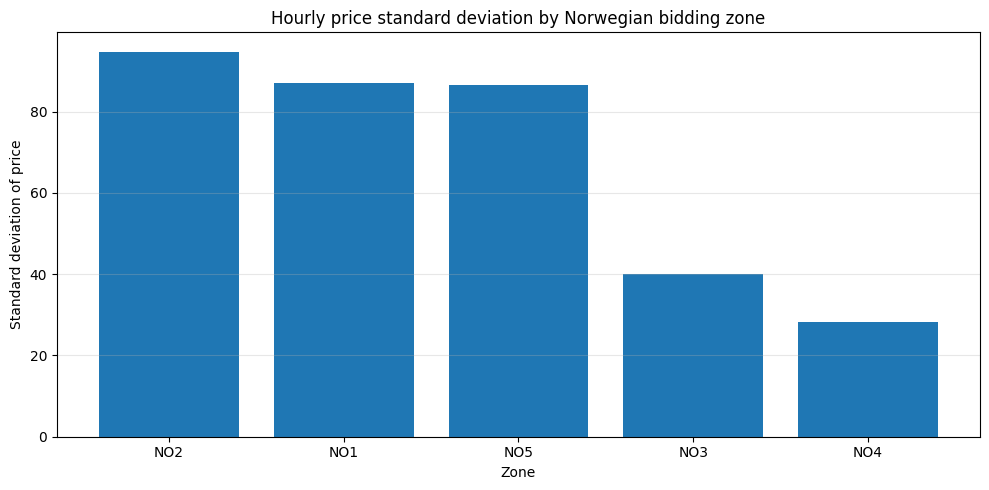

In [10]:
# ============================================================
# 8. BAR PLOT - STANDARD DEVIATION BY ZONE
# ============================================================

plot_df = volatility_ranking.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["zone_code"], plot_df["std_price"])

plt.title("Hourly price standard deviation by Norwegian bidding zone")
plt.xlabel("Zone")
plt.ylabel("Standard deviation of price")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 9. PREPARE DATA FOR BOXPLOT
# ============================================================

boxplot_data = []

for zone, df_zone in zone_price_data.items():
    temp = df_zone[["price_value"]].copy()
    temp["zone_code"] = zone
    boxplot_data.append(temp)

boxplot_df = pd.concat(boxplot_data, ignore_index=True)

boxplot_df.head()

,price_value,zone_code
0,31.82,NO1
1,31.77,NO1
2,31.57,NO1
3,31.28,NO1
4,30.72,NO1


<Figure size 1200x600 with 0 Axes>

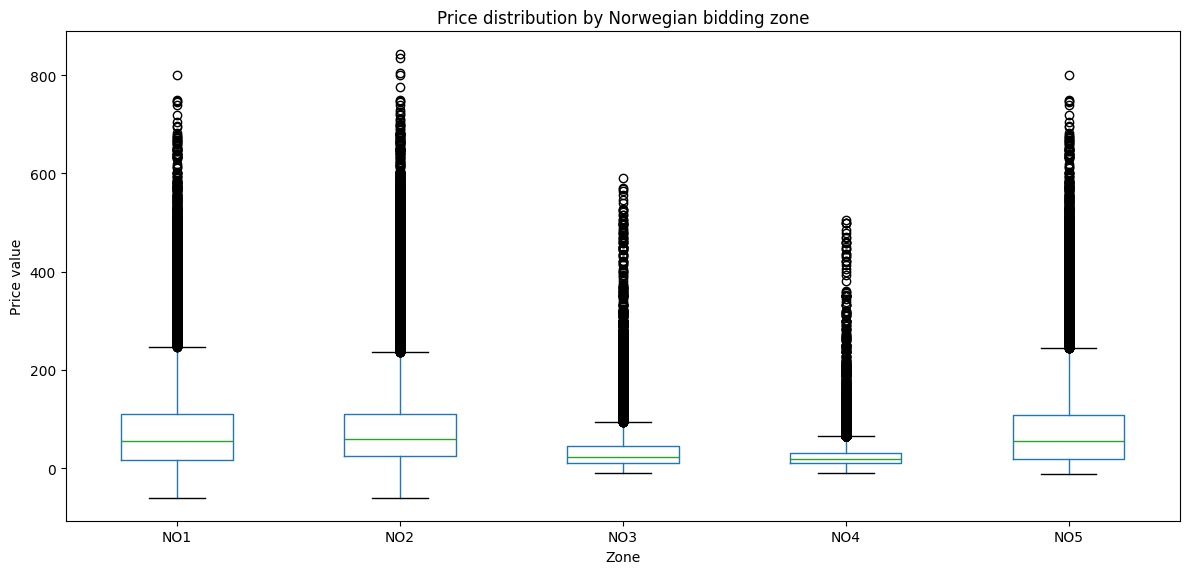

In [12]:
# ============================================================
# 10. BOXPLOT OF PRICE DISTRIBUTIONS BY ZONE
# ============================================================

plt.figure(figsize=(12, 6))

boxplot_df.boxplot(
    column="price_value",
    by="zone_code",
    grid=False,
    figsize=(12, 6)
)

plt.title("Price distribution by Norwegian bidding zone")
plt.suptitle("")
plt.xlabel("Zone")
plt.ylabel("Price value")
plt.tight_layout()
plt.show()

## **CALIBRATION PERIOD**